# Investigating the Scouting MC "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"

## Import and Data

In [1]:
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea.analysis_tools import PackedSelection

import dask_awkward as dak

import itertools as iter

import hist
from hist import Hist

In [2]:
class ScoutingNanoAODSchema(NanoAODSchema):

    mixins = {
        **NanoAODSchema.mixins,
        "ScoutingJet": "Jet" 
    }

In [3]:
file_list = [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] + [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]

NanoAODSchema.warn_missing_crossrefs = False

events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:4]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

#uproot.concatenate(file_list)

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2024.7.0 (target date: 2024-06-30 11:59:59-05:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


## Basic Variables

Text(0.5, 0, 'Number of Charged Leptons Per Event')

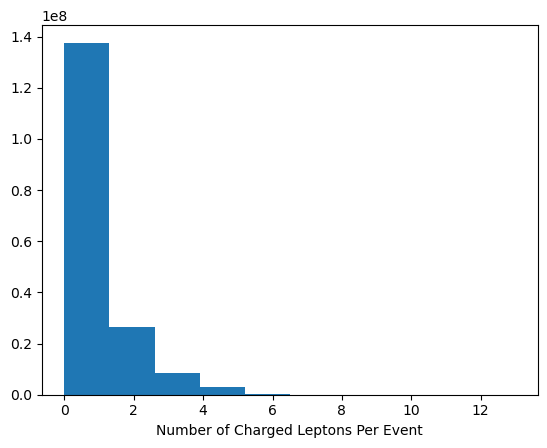

In [40]:
plt.hist(np.add(ak.count(events.ScoutingMuon.pt.compute(),axis=1), ak.count(events.ScoutingElectron.pt.compute(),axis=1)))

plt.xlabel("Number of Charged Leptons Per Event")

Text(0.5, 0, 'Number of Jets Per Event')

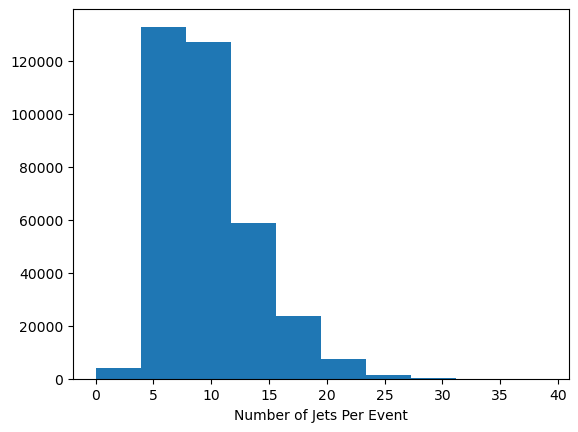

In [26]:
plt.hist(ak.count(small_events.ScoutingJet.pt.compute(),axis=1))

plt.xlabel("Number of Jets Per Event")

## Gen Jet Triplets

In [7]:
selection = PackedSelection()

selection.add("SixJets", ak.num(small_events.GenJet) > 5)
selection.add("OneB", ak.sum(small_events.GenJet.partonFlavour == 5, axis=1) == 1)
selection.add("OneC", ak.sum(small_events.GenJet.partonFlavour == 4, axis=1) == 1)
selection.add("OneS", ak.sum(small_events.GenJet.partonFlavour == 3, axis=1) == 1)
selection.add("OneAB", ak.sum(small_events.GenJet.partonFlavour == -5, axis=1) == 1)
selection.add("OneAC", ak.sum(small_events.GenJet.partonFlavour == -4, axis=1) == 1)
selection.add("OneAS", ak.sum(small_events.GenJet.partonFlavour == -3, axis=1) == 1)

selection.names


['SixJets', 'OneB', 'OneC', 'OneS', 'OneAB', 'OneAC', 'OneAS']

Text(0.5, 0, 'Mass of all 20 triplets of GenJets [GeV]')

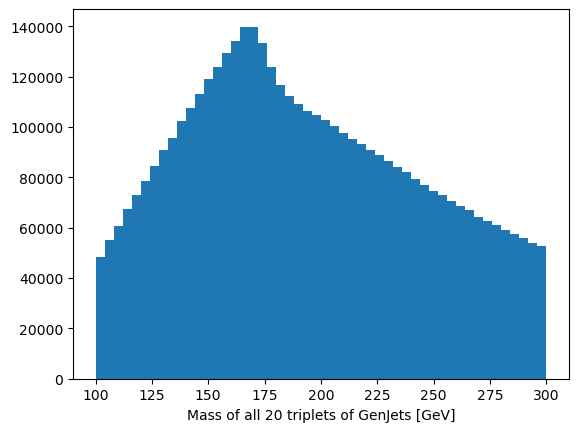

In [8]:
m_events = small_events[selection.all("SixJets")]

arr = []
for comb in iter.combinations(range(6),3):
    j1 = m_events.GenJet[:,comb[0]]
    j2 = m_events.GenJet[:,comb[1]]
    j3 = m_events.GenJet[:,comb[2]]
    arr.append((j1 + j2 + j3).mass.compute())


plt.hist(np.array(arr).flatten(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of all 20 triplets of GenJets [GeV]")

Text(0.5, 0, 'Mass of b + c + s GenJets [GeV]')

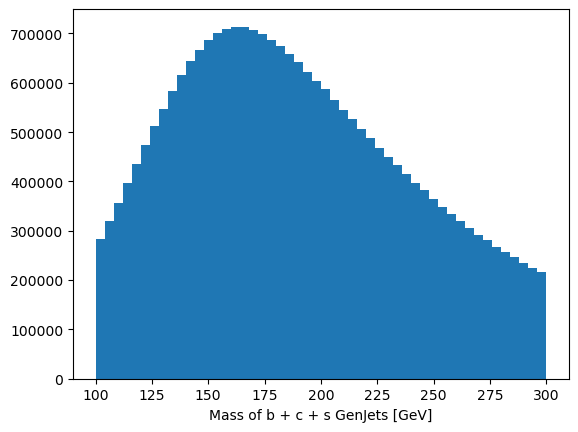

In [10]:
m_events = events[selection.all("OneB", "OneC", "OneS")]

bj = m_events.GenJet[m_events.GenJet.partonFlavour == 5]
cj = m_events.GenJet[m_events.GenJet.partonFlavour == 4]
sj = m_events.GenJet[m_events.GenJet.partonFlavour == 3]


top = bj + cj + sj
plt.hist(top.mass.compute(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of b + c + s GenJets [GeV]")

Text(0.5, 0, 'Mass of b + c + as GenJets [GeV]')

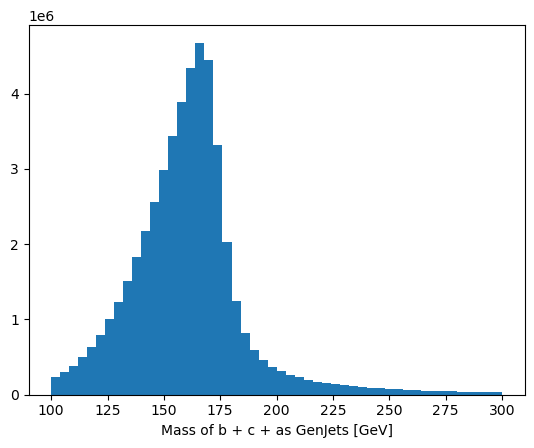

In [12]:
m_events = events[selection.all("OneB", "OneC", "OneAS")]

#I should check this versus the other quark flavor combinations
#and look at the GenPart deltaR method
bj = m_events.GenJet[m_events.GenJet.partonFlavour == 5]
cj = m_events.GenJet[m_events.GenJet.partonFlavour == 4]
asj = m_events.GenJet[m_events.GenJet.partonFlavour == -3]


top = bj + cj + asj
plt.hist(top.mass.compute(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of b + c + as GenJets [GeV]")

## Scouting Jet Triplets

In [5]:
scouting_selection = PackedSelection()

scouting_selection.add("SixJets", ak.num(small_events.ScoutingJet) > 5)
scouting_selection.add("OneB", ak.sum(small_events.GenJet.partonFlavour == 5, axis=1) == 1)
scouting_selection.add("OneC", ak.sum(small_events.GenJet.partonFlavour == 4, axis=1) == 1)
scouting_selection.add("OneS", ak.sum(small_events.GenJet.partonFlavour == 3, axis=1) == 1)
scouting_selection.add("OneAB", ak.sum(small_events.GenJet.partonFlavour == -5, axis=1) == 1)
scouting_selection.add("OneAC", ak.sum(small_events.GenJet.partonFlavour == -4, axis=1) == 1)
scouting_selection.add("OneAS", ak.sum(small_events.GenJet.partonFlavour == -3, axis=1) == 1)
#scouting_selection.add("MatchB", small_events.GenJet[:,small_events.ScoutingJet.genJetIdx].partonFlavour == 5)

Text(0.5, 0, 'Mass of all 20 triplets of ScoutingJets [GeV]')

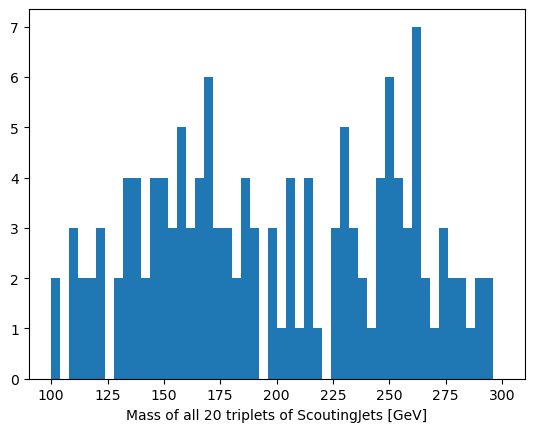

In [24]:
m_events = small_events[scouting_selection.all("SixJets")]

m_events = m_events[0:10]


arr = []
for comb in iter.combinations(range(6),3):
    j1 = m_events.ScoutingJet[:,comb[0]]
    j2 = m_events.ScoutingJet[:,comb[1]]
    j3 = m_events.ScoutingJet[:,comb[2]]
    
    arr.append((j1 + j2 + j3).mass.compute())


plt.hist(np.array(arr).flatten(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of all 20 triplets of ScoutingJets [GeV]")


In [4]:
def triplet_mass_from_flavor(ev, i, j, k):
    selector = PackedSelection()
    selector.add("ThreeJets", ak.num(ev.ScoutingJet) > 2)
    selector.add("OneMatchI", ak.sum(ev.ScoutingJet.nearest(ev.GenJet).partonFlavour == i, axis=1) == 1)
    selector.add("OneMatchJ", ak.sum(ev.ScoutingJet.nearest(ev.GenJet).partonFlavour == j, axis=1) == 1)
    selector.add("OneMatchK", ak.sum(ev.ScoutingJet.nearest(ev.GenJet).partonFlavour == k, axis=1) == 1)
    
    m_ev = ev[selector.all("ThreeJets","OneMatchI","OneMatchJ","OneMatchK")]

    #m_ev = m_ev[0:20]
    aj = m_ev.ScoutingJet[m_ev.ScoutingJet.nearest(m_ev.GenJet).partonFlavour == i]
    bj = m_ev.ScoutingJet[m_ev.ScoutingJet.nearest(m_ev.GenJet).partonFlavour == j]
    cj = m_ev.ScoutingJet[m_ev.ScoutingJet.nearest(m_ev.GenJet).partonFlavour == k]
    return ak.flatten((aj + bj + cj).mass)

In [21]:
small_events.ScoutingJet.

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7ff502b64b50>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

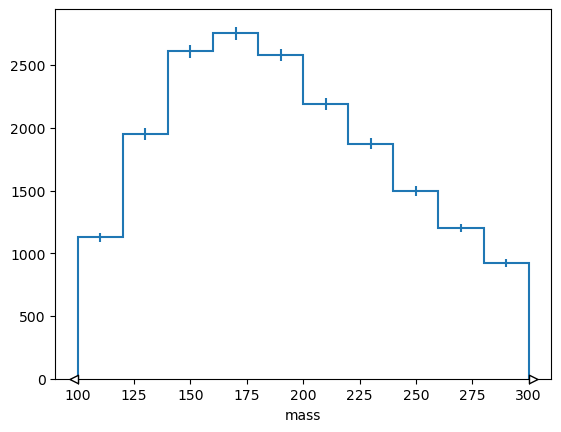

In [31]:
sc_wrong = Hist(hist.axis.Regular(bins=10, start=100, stop=300, name="mass"))

sc_wrong.fill(mass=triplet_mass_from_flavor(small_events,3,4,5).compute())
sc_wrong.plot1d()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7ff502c38fa0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

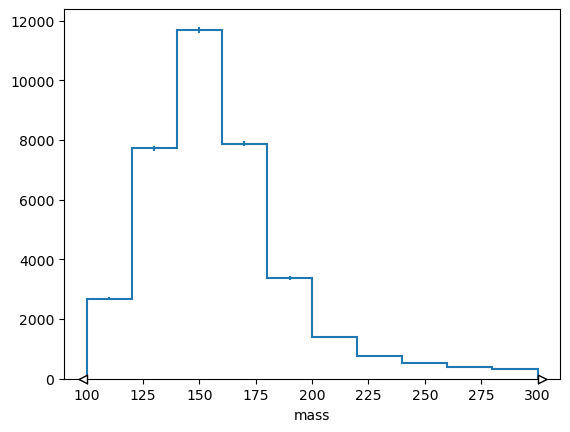

In [41]:
sc_right= Hist(hist.axis.Regular(bins=10, start=100, stop=300, name="mass"))

sc_right.fill(mass=triplet_mass_from_flavor(small_events,-3,4,5).compute())
sc_right.plot1d()

In [12]:
m_events = small_events[scouting_selection.all("SixJets","OneB", "OneC", "OneAS")]


#cj = m_events.ScoutingJet[m_events.GenJet.partonFlavour == 4]
#asj = m_events.ScoutingJet[m_events.GenJet.partonFlavour == -3]
bj = m_events.ScoutingJet[m_events.GenJet.partonFlavour == 5]

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7ff52835ad40>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

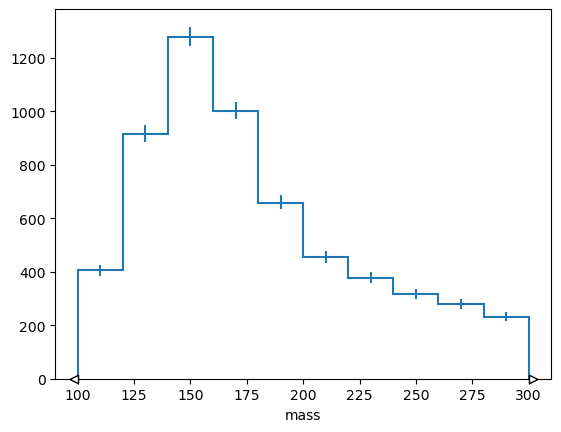

In [34]:
sc_wrong = Hist(hist.axis.Regular(bins=10, start=100, stop=300, name="mass"))

sc_wrong.fill(mass=triplet_mass_from_flavor(small_events,-1,4,5).compute())
sc_wrong.plot1d()